---
# Assignment 2: Data Visualization with Matplotlib
---
## Student Information
**Name:**  ____Marah Ahmad Aljabali______
**Student ID:**  _______220210525__________
**Date:** ______27 Dec 2025_______

## Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# Set style for better looking plots
plt.style.use('seaborn-v0_8')

# Magic command for inline plotting
%matplotlib inline

# Part A: Basic Plotting

### Q1: Trigonometric Functions Plotting
Create a figure with 3 subplots (arranged vertically) showing:
1. Sine function from -2π to 2π with 200 samples
2. Cosine function from -2π to 2π with 200 samples  
3. Tangent function from -2π to 2π with 200 samples

**Requirements:**
- Each subplot should have proper titles and axis labels
- Use different colors for each function
- Add gridlines to all plots
- Set appropriate x-axis ticks at -2π, -π, 0, π, 2π

C:\Users\HP\AppData\Local\Temp\ipykernel_25864\1544404635.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


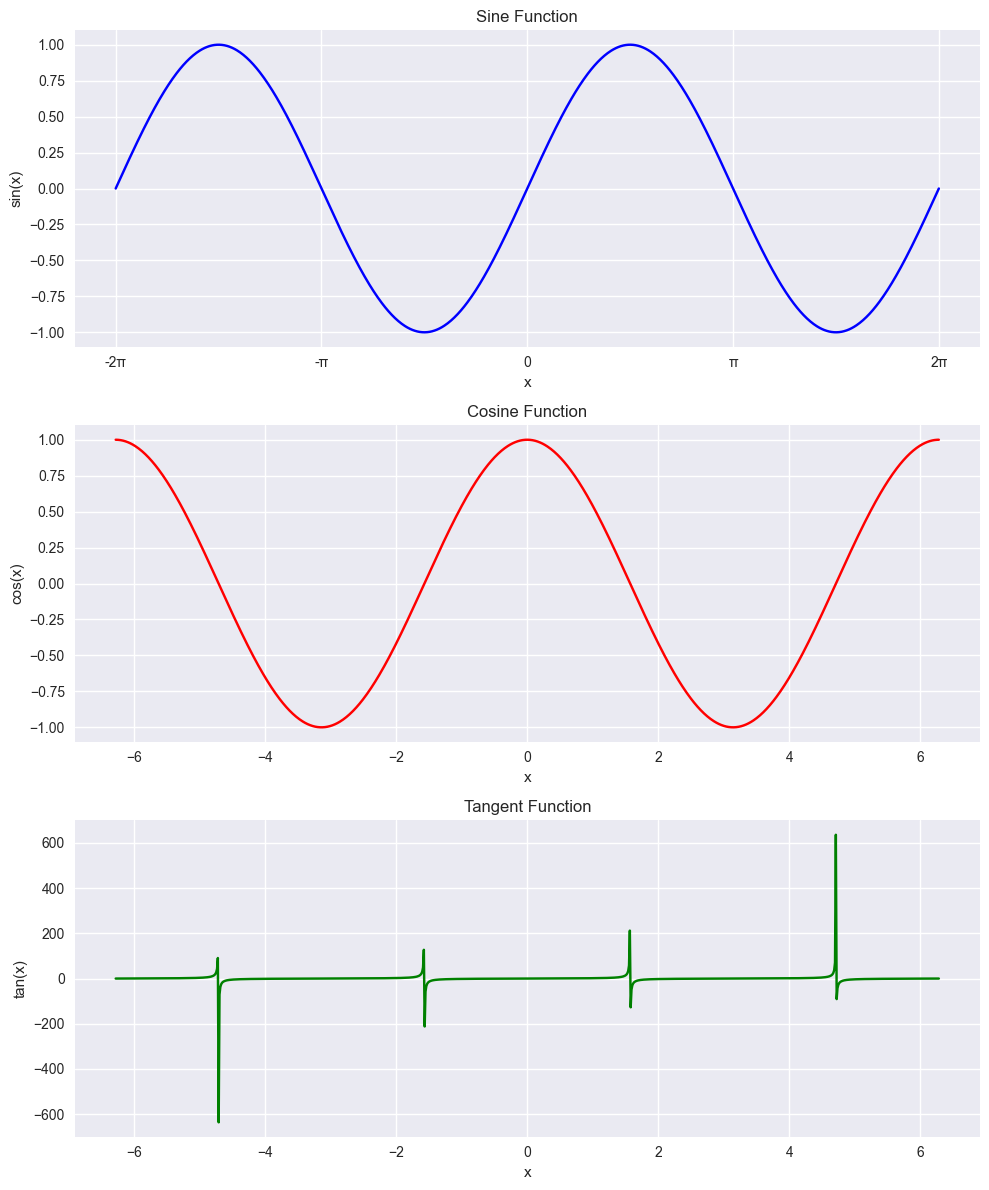

In [5]:
# Your solution for Q1 here

# Step 1: Create x values from -2π to 2π
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)

# Step 2: Calculate y values for sin, cos, tan
y_sin = np.sin(x)
y_cos = np.cos(x)
y_tan = np.tan(x)
# Step 3: Create figure with 3 subplots (vertical arrangement)
fig = plt.figure(figsize=(10, 12))
ax1 = fig.add_subplot(3, 1, 1)
ax2 = fig.add_subplot(3, 1, 2)
ax3 = fig.add_subplot(3, 1, 3)
# Step 4: Plot sine function
ax1.plot(x, y_sin, color='blue')
ax1.set_title('Sine Function')
ax1.set_ylabel('sin(x)')
ax1.grid(True)

# Step 5: Plot cosine function
ax2.plot(x, y_cos, color='red')
ax2.set_title('Cosine Function')
ax2.set_ylabel('cos(x)')
ax2.grid(True)

# Step 6: Plot tangent function
ax3.plot(x, y_tan, color='green')
ax3.set_title('Tangent Function')
ax3.set_ylabel('tan(x)')
ax3.grid(True)

# Step 7: Add titles, labels, grid, and custom x-ticks
ax1.set_xlabel('x')
ax2.set_xlabel('x')
ax3.set_xlabel('x')
ax1.set_xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi])
ax1.set_xticklabels(["-2π", "-π", "0", "π", "2π"])

# Step 8: Adjust layout and display
plt.tight_layout()
fig.show()

### Q2: Multi-resolution Comparison
Plot the sine function in a 2×2 subplot grid with different sample resolutions:
1. Top-left: 10 samples
2. Top-right: 50 samples
3. Bottom-left: 100 samples
4. Bottom-right: 500 samples

Show how increasing samples improves the smoothness of the curve.

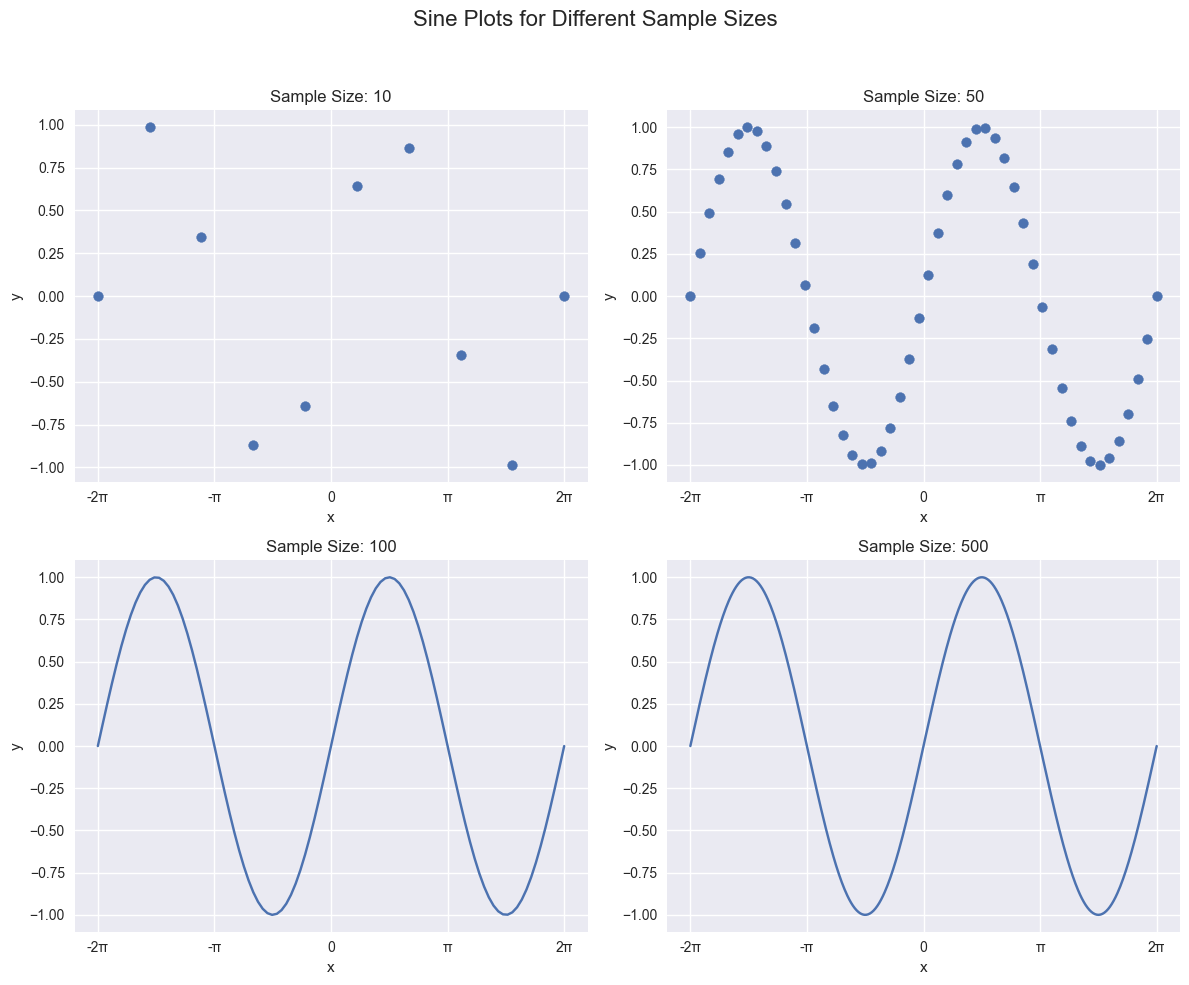

In [16]:
# Your solution for Q2 here

# Step 1: Define different sample sizes
samples_list = [10, 50, 100, 500]

# Step 2: Create 2x2 subplot grid
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)
axes = [ax1, ax2, ax3, ax4]

# Step 3: Loop through each sample size and plot
for ax, sample in zip(axes, samples_list):
  x_sample = np.linspace(-2 * np.pi, 2 * np.pi, sample)
  y_sample = np.sin(x_sample)
  # Use scatter for low-res, line for higher-res
  if sample <= 50:
    ax.scatter(x_sample, y_sample)
  else:
    ax.plot(x_sample, y_sample)
  ax.set_title(f'Sample Size: {sample}')
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi])
  ax.set_xticklabels(["-2π", "-π", "0", "π", "2π"])
  ax.grid(True)

# Step 4: Add titles, labels, and grid
plt.suptitle('Sine Plots for Different Sample Sizes', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Q3: Custom Bar Chart
Create a bar chart showing the grades distribution of a class:
- Grades: A, B, C, D, F
- Number of students: [8, 12, 15, 5, 2]

**Requirements:**
- Use different colors for each grade
- Add value labels on top of each bar
- Add a title "Grade Distribution - Class A"
- Set y-axis label to "Number of Students"

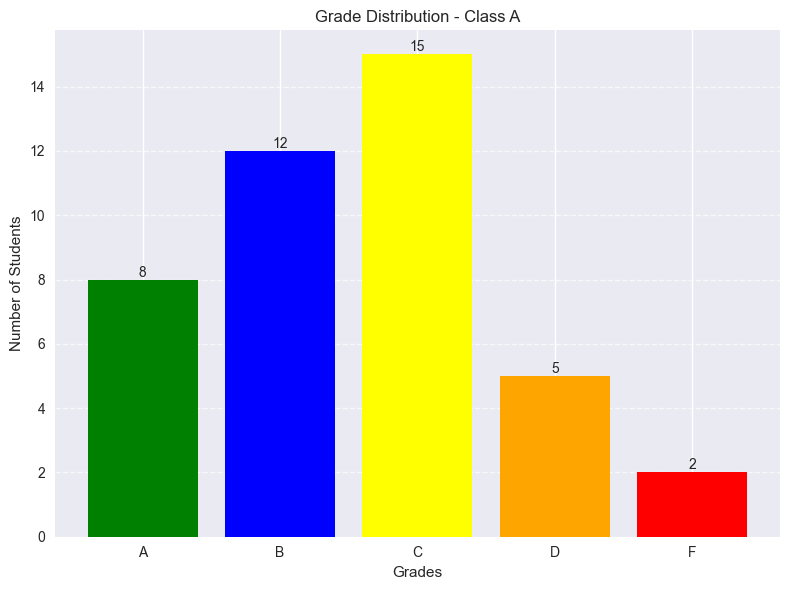

In [21]:
# Your solution for Q3 here

# Step 1: Define data
grades = ['A', 'B', 'C', 'D', 'F']
students = [8, 12, 15, 5, 2]

# Step 2: Define colors for each bar
colors = ['green', 'blue', 'yellow', 'orange', 'red'] 
# Step 3: Create bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(grades, students, color=colors)

# Step 4: Add value labels on top of bars
for bar in bars:
  height = bar.get_height()
  ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')

# Step 5: Add title and labels
ax.set_title('Grade Distribution - Class A')
ax.set_ylabel('Number of Students')
ax.set_xlabel('Grades')

# Step 6: Customize appearance
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Part B: Data Analysis & Visualization

### Q4: COVID-19 Data Analysis
Load the files `covid_gaza_data.npy` and `covid_gaza_date.npy` and:

1. Create a 2×2 subplot showing:
   - Top-left: Daily cases (line plot)
   - Top-right: Daily deaths (line plot) 
   - Bottom-left: Daily recoveries (line plot)
   - Bottom-right: Active cases (line plot)

2. Calculate and plot:
   - 7-day moving average of new cases
   - Daily growth rate percentage

**Note:** The data has 4 columns: [Cases, Deaths, Recoveries, Active Cases]

COVID data shape: (300, 4)
Dates shape: (300,)


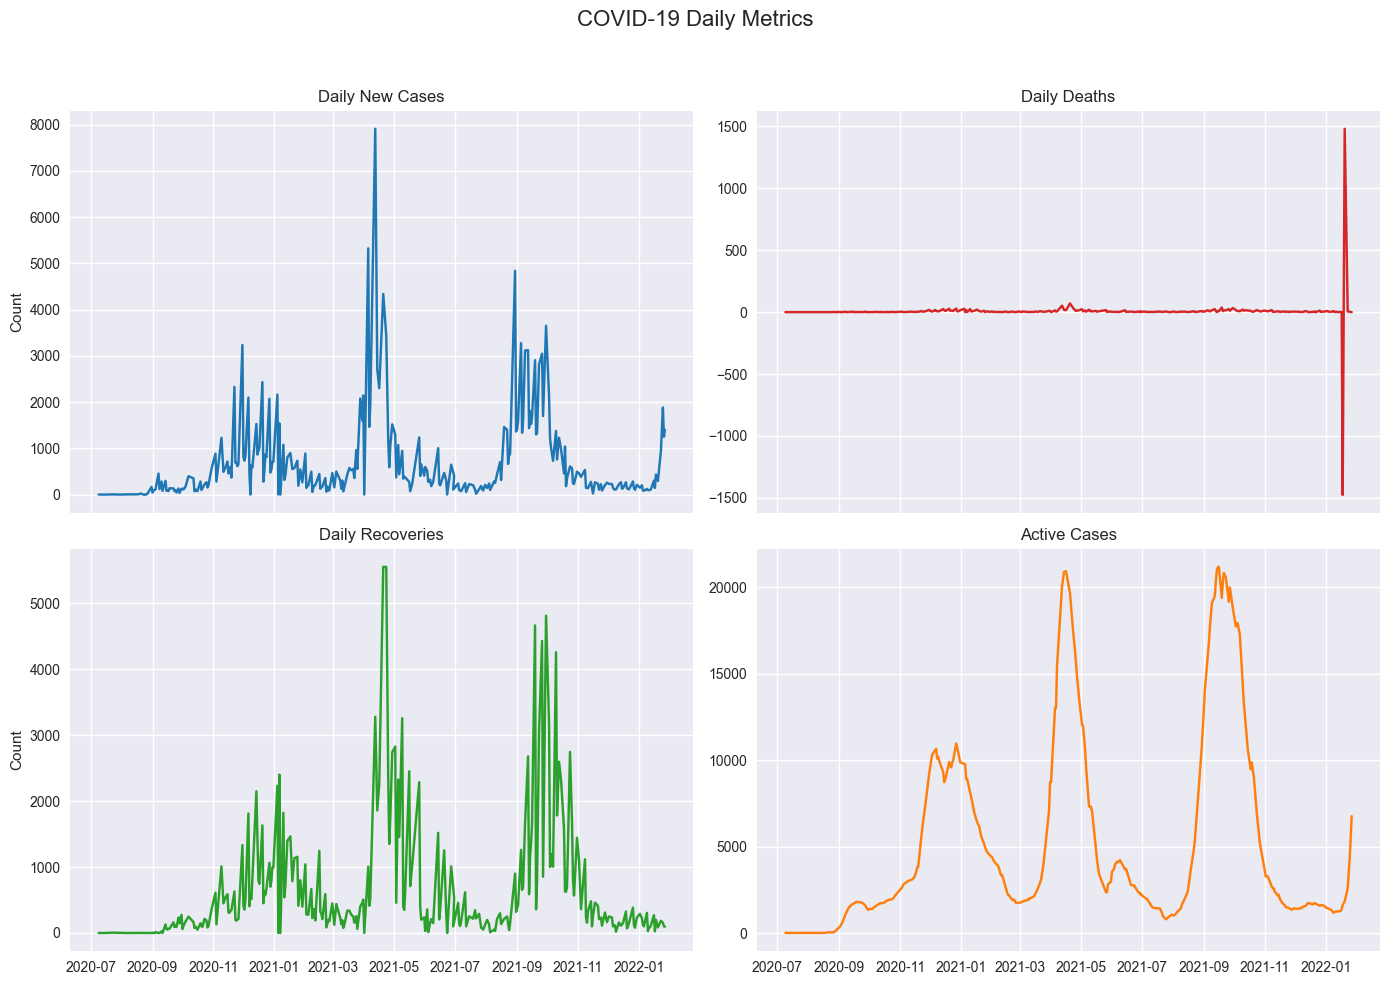

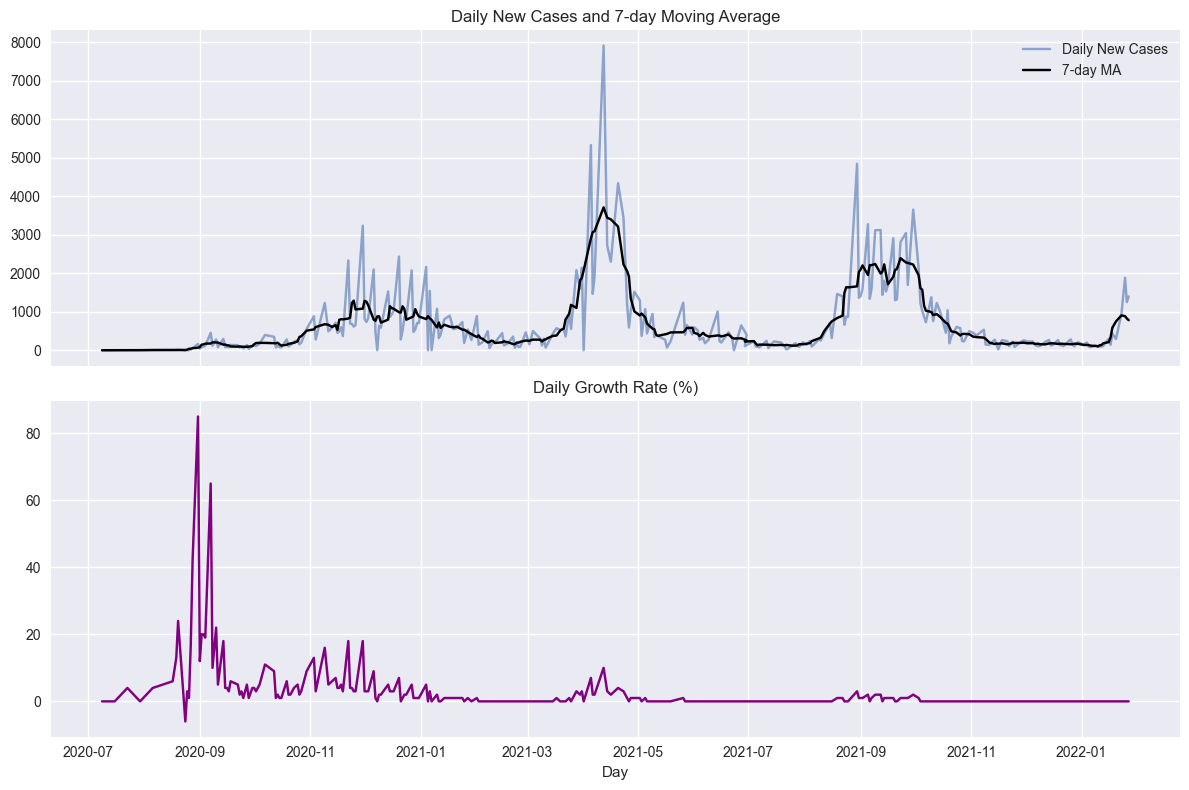

In [27]:
# Your solution for Q4 here

# Step 1: Load the data files
try:
  covid_data = np.load('covid_gaza_data.npy')
  covid_dates = np.load('covid_gaza_date.npy')
  print(f"COVID data shape: {covid_data.shape}")
  print(f"Dates shape: {covid_dates.shape}")
except FileNotFoundError as e:
  print(f"Error: {e}")
  # Create sample data for testing
  covid_data = np.random.rand(100, 4) * 100
  covid_dates = np.arange(100)

# Step 2: Prepare series and x-axis
cases_cum = covid_data[:, 0]
deaths_cum = covid_data[:, 1]
recoveries_cum = covid_data[:, 2]
active = covid_data[:, 3]

x = covid_dates if len(covid_dates) == len(cases_cum) else np.arange(len(cases_cum))

# Compute daily values from cumulative (safe even if data already daily)
new_cases = np.diff(cases_cum, prepend=cases_cum[0])
new_deaths = np.diff(deaths_cum, prepend=deaths_cum[0])
new_recoveries = np.diff(recoveries_cum, prepend=recoveries_cum[0])

# Step 3: Create 2x2 subplot for basic metrics (daily series)
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axs = axs.flatten()
axs[0].plot(x, new_cases, color='tab:blue')
axs[0].set_title('Daily New Cases')
axs[0].set_ylabel('Count')
axs[1].plot(x, new_deaths, color='tab:red')
axs[1].set_title('Daily Deaths')
axs[2].plot(x, new_recoveries, color='tab:green')
axs[2].set_title('Daily Recoveries')
axs[2].set_ylabel('Count')
axs[3].plot(x, active, color='tab:orange')
axs[3].set_title('Active Cases')

for ax in axs:
  ax.grid(True)

plt.suptitle('COVID-19 Daily Metrics', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Step 4: Calculate 7-day moving average of new cases (same length)
moving_avg = np.convolve(new_cases, np.ones(7)/7, mode='same')

# Step 5: Calculate daily growth rate (%) based on cumulative cases
growth_rate = np.zeros_like(cases_cum)
prev = cases_cum[:-1]
nonzero = prev != 0
growth_rate[1:][nonzero] = (cases_cum[1:][nonzero] - prev[nonzero]) / prev[nonzero] * 100

# Step 6: Plot moving average and growth rate
fig2, (a1, a2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
a1.plot(x, new_cases, alpha=0.6, label='Daily New Cases')
a1.plot(x, moving_avg, color='black', label='7-day MA')
a1.set_title('Daily New Cases and 7-day Moving Average')
a1.legend()
a1.grid(True)

a2.plot(x, growth_rate, color='purple')
a2.set_title('Daily Growth Rate (%)')
a2.set_xlabel('Day')
a2.grid(True)

plt.tight_layout()
plt.show()


### Q6: Statistical Visualization
For the COVID-19 data, create:

1. A pie chart showing the proportion of:
   - Total Cases
   - Total Deaths  
   - Total Recoveries
   - Active Cases (at the end of the period)

2. A scatter plot with:
   - X-axis: Daily new cases
   - Y-axis: Daily new deaths
   - Point size: Based on active cases
   - Color: Based on day number (use a colormap)

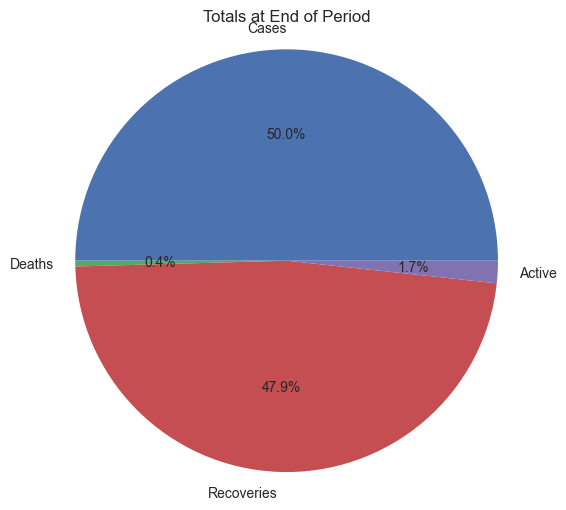

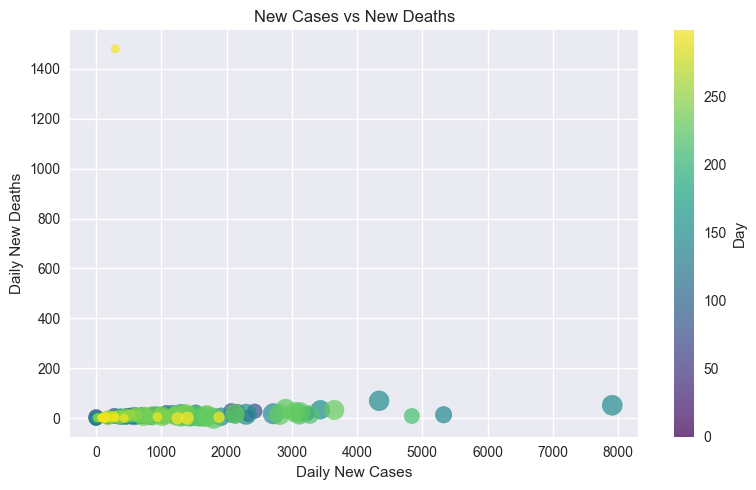

In [40]:

# Ensure data is available
cases = covid_data[:, 0]
deaths = covid_data[:, 1]
recoveries = covid_data[:, 2]
active = covid_data[:, 3]

# Pie chart (نسب القيم في نهاية الفترة)
labels = ['Cases', 'Deaths', 'Recoveries', 'Active']
sizes = [cases[-1], deaths[-1], recoveries[-1], active[-1]]
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Totals at End of Period')
plt.axis('equal')
plt.show()

# Scatter: حالات جديدة مقابل وفيات جديدة (أحجام بسيطة)
new_cases = np.maximum(np.diff(cases, prepend=cases[0]), 0)
new_deaths = np.maximum(np.diff(deaths, prepend=deaths[0]), 0)
# حجم بسيط ومفهوم: مقياس يعتمد على أقصى قيمة للحالة
sizes = (active / (active.max() + 1e-6)) * 200 + 20
plt.figure(figsize=(8,5))
plt.scatter(new_cases, new_deaths, s=sizes, c=np.arange(len(new_cases)), cmap='viridis', alpha=0.7)
plt.colorbar(label='Day')
plt.xlabel('Daily New Cases')
plt.ylabel('Daily New Deaths')
plt.title('New Cases vs New Deaths')
plt.grid(True)
plt.tight_layout()
plt.show()


# Part C: Advanced Visualization

### Q7: Matrix Visualization
Create a 10×10 matrix where:
- Diagonal elements = 1
- Elements adjacent to diagonal = 0.5  
- All other elements = 0.1

Visualize this matrix using:
1. `plt.matshow()` with a colorbar
2. `plt.imshow()` with interpolation='nearest'
3. A heatmap with annotated values for the first 3×3 corner

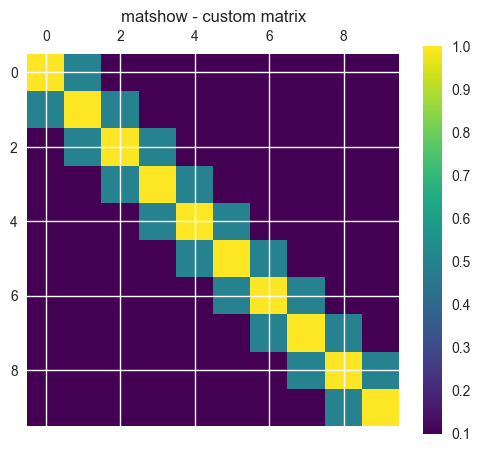

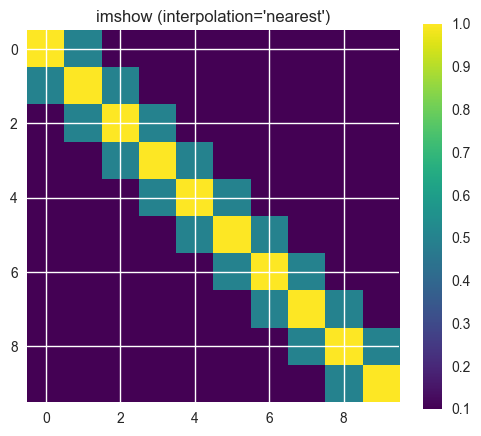

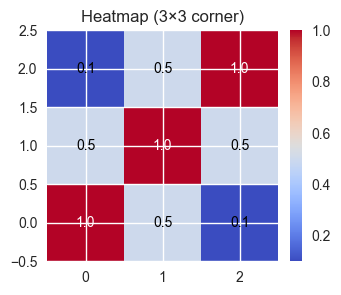

In [ ]:
# Your solution for Q7 here

# Step 1: Create the 10x10 matrix
n = 10
M = np.full((n, n), 0.1)
# diagonal = 1, adjacent = 0.5
for i in range(n):
  M[i, i] = 1.0
  if i + 1 < n:
    M[i, i+1] = 0.5
    M[i+1, i] = 0.5

# Step 2: Method 1 - Using plt.matshow()
plt.figure(figsize=(6, 5))
plt.matshow(M, fignum=1, cmap='viridis')
plt.colorbar()
plt.title('matshow - custom matrix')
plt.show()

# Step 3: Method 2 - Using plt.imshow() with interpolation
plt.figure(figsize=(6, 5))
plt.imshow(M, interpolation='nearest', cmap='viridis')
plt.colorbar()
plt.title("imshow (interpolation='nearest')")
plt.show()

# Step 4: Method 3 - Heatmap with annotations for the first 3x3 corner
plt.figure(figsize=(4, 3))
im = plt.imshow(M[:3, :3], cmap='coolwarm', interpolation='nearest')
# Annotate the cells
for i in range(3):
  for j in range(3):
    val = M[i, j]
    color = 'white' if val > 0.55 else 'black'
    plt.text(j, i, f'{val:.1f}', ha='center', va='center', color=color)
plt.title('Heatmap (3×3 corner)')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.gca().invert_yaxis()
plt.show()


### Q8: Website Visitors Analysis
Load `visitors.npy` and:

1. Reshape the data to show weekly patterns (weeks × days)
2. Create a heatmap showing visitors per day of week
3. Calculate and plot:
   - Average visitors per day of week
   - Total visitors per week
   - Identify the busiest day and week

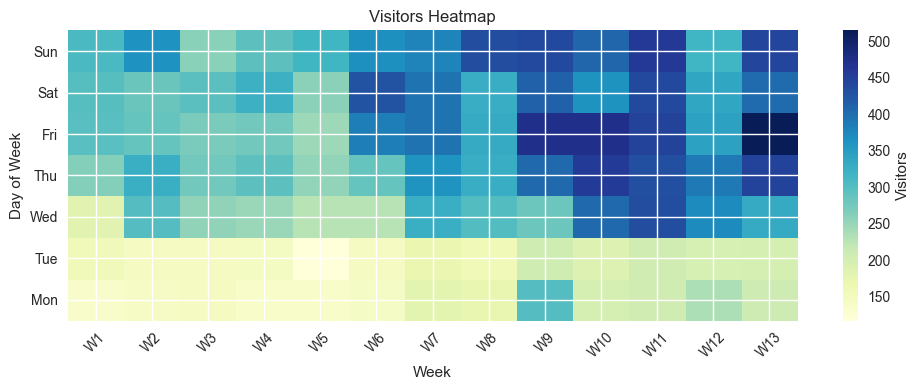

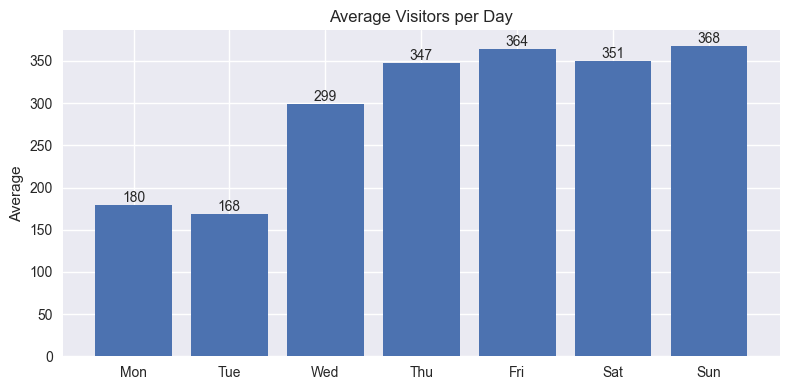

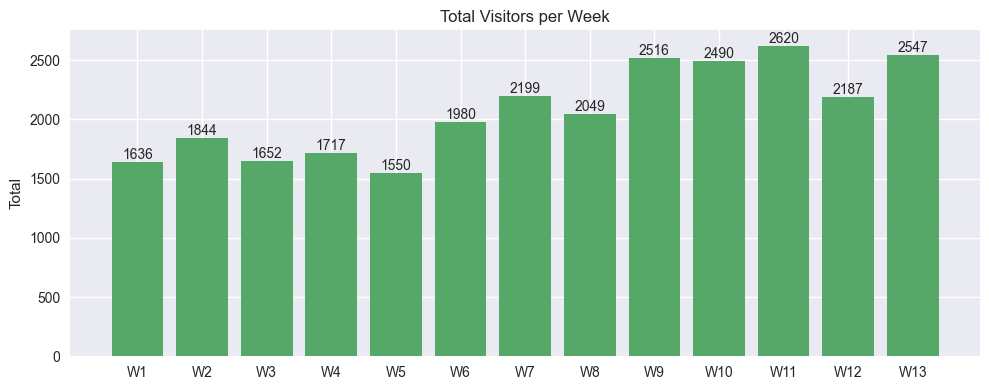

Busiest day (avg): Sun -> 368
Busiest week: Week 11 -> 2620


In [ ]:

visitors = np.load('visitors.npy')

n = len(visitors)
if n >= 7:
  n_full = (n // 7) * 7
  weeks = visitors[:n_full].reshape(-1, 7)
else:
  weeks = visitors.reshape(1, -1)

num_weeks, days_per_week = weeks.shape
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][:days_per_week]

# Heatmap
plt.figure(figsize=(10,4))
plt.imshow(weeks.T, aspect='auto', cmap='YlGnBu', origin='lower')
plt.yticks(range(days_per_week), day_labels)
plt.xticks(range(num_weeks), [f'W{k+1}' for k in range(num_weeks)], rotation=45)
plt.colorbar(label='Visitors')
plt.title('Visitors Heatmap')
plt.xlabel('Week')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

# Average per day
avg_per_day = weeks.mean(axis=0)
plt.figure(figsize=(8,4))
for i, v in enumerate(avg_per_day):
  plt.bar(day_labels[i], v, color='C0')
  plt.text(i, v, f'{v:.0f}', ha='center', va='bottom')
plt.title('Average Visitors per Day')
plt.ylabel('Average')
plt.tight_layout()
plt.show()

# Totals per week
totals_per_week = weeks.sum(axis=1)
plt.figure(figsize=(10,4))
plt.bar([f'W{k+1}' for k in range(num_weeks)], totals_per_week, color='C1')
for i, v in enumerate(totals_per_week):
  plt.text(i, v, f'{v:.0f}', ha='center', va='bottom')
plt.title('Total Visitors per Week')
plt.ylabel('Total')
plt.tight_layout()
plt.show()

# Busiest day/week
busiest_day = day_labels[np.argmax(avg_per_day)]
print(f'Busiest day (avg): {busiest_day} -> {avg_per_day.max():.0f}')
print(f'Busiest week: Week {np.argmax(totals_per_week)+1} -> {totals_per_week.max():.0f}')


### Q9: Composite Visualization
Create a dashboard-style figure with:

1. **Top-left:** Line plot of sine and cosine functions (0 to 4π)
2. **Top-right:** Scatter plot of random data with size and color variations
3. **Bottom-left:** Bar chart comparing function values at key points (0, π/2, π, 3π/2, 2π)
4. **Bottom-right:** Pie chart showing the quadrant distribution of 1000 random points

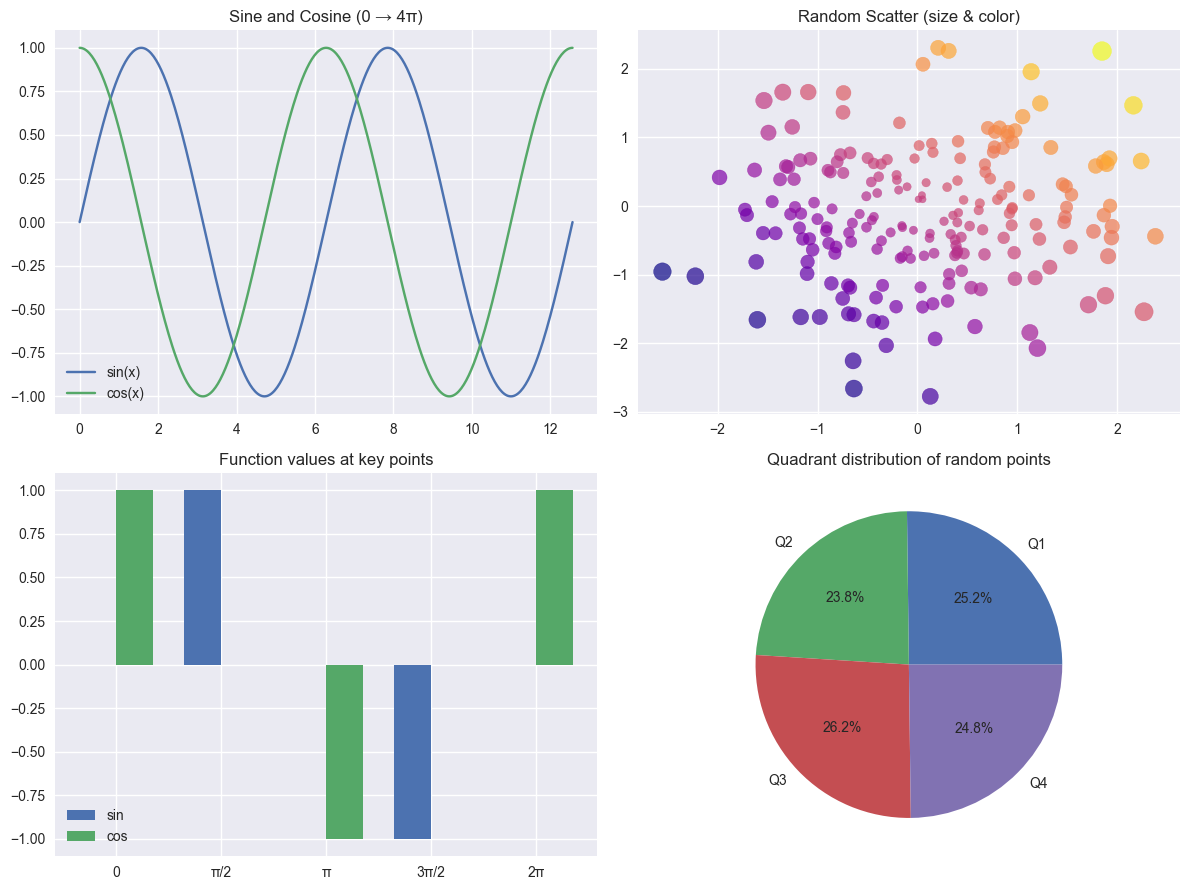

In [61]:
# Q9 - Composite dashboard (fixed and beginner-friendly)
import numpy as np
x = np.linspace(0, 4 * np.pi, 400)
fig, axs = plt.subplots(2, 2, figsize=(12, 9))

# Top-left: Line plot - sine & cosine
axs[0, 0].plot(x, np.sin(x), label='sin(x)')
axs[0, 0].plot(x, np.cos(x), label='cos(x)')
axs[0, 0].set_title('Sine and Cosine (0 → 4π)')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Top-right: Scatter of random data with size & color
np.random.seed(0)
x_r = np.random.randn(200)
y_r = np.random.randn(200)
sizes = (np.abs(x_r) + np.abs(y_r)) * 40 + 20
colors = x_r + y_r
axs[0, 1].scatter(x_r, y_r, s=sizes, c=colors, cmap='plasma', alpha=0.7)
axs[0, 1].set_title('Random Scatter (size & color)')
axs[0, 1].grid(True)

# Bottom-left: Bar chart comparing function values at key points
points = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
labels = ['0', 'π/2', 'π', '3π/2', '2π']
sin_vals = np.sin(points)
cos_vals = np.cos(points)
idx = np.arange(len(points))
width = 0.35
axs[1, 0].bar(idx - width/2, sin_vals, width, label='sin')
axs[1, 0].bar(idx + width/2, cos_vals, width, label='cos')
axs[1, 0].set_xticks(idx)
axs[1, 0].set_xticklabels(labels)
axs[1, 0].set_title('Function values at key points')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Bottom-right: Pie chart showing quadrant distribution of random points
pts = np.random.randn(1000, 2)
# compute counts for each quadrant first
q1 = np.sum((pts[:, 0] >= 0) & (pts[:, 1] >= 0))
q2 = np.sum((pts[:, 0] < 0) & (pts[:, 1] >= 0))
q3 = np.sum((pts[:, 0] < 0) & (pts[:, 1] < 0))
q4 = np.sum((pts[:, 0] >= 0) & (pts[:, 1] < 0))
counts = [int(q1), int(q2), int(q3), int(q4)]
axs[1, 1].pie(counts, labels=['Q1', 'Q2', 'Q3', 'Q4'], autopct='%1.1f%%')
axs[1, 1].set_title('Quadrant distribution of random points')

plt.tight_layout()
plt.show()

### Q10: Visualization Task
Create an informative visualization about student performance with:

1. **Input Data:**
   ```python
   students = ['Ali', 'Sara', 'Omar', 'Layla', 'Youssef', 'Noura']
   math_scores = [85, 92, 78, 95, 88, 90]
   science_scores = [88, 94, 82, 96, 85, 92]
   english_scores = [82, 90, 76, 93, 87, 89]
   attendance = [95, 98, 92, 99, 96, 97]
   ```

2. **Requirements:**
   - A radar chart showing each student's performance in all subjects
   - A grouped bar chart comparing subjects across students
   - A scatter plot showing correlation between attendance and average score
   - A composite visualization of your choice that tells a story about the data

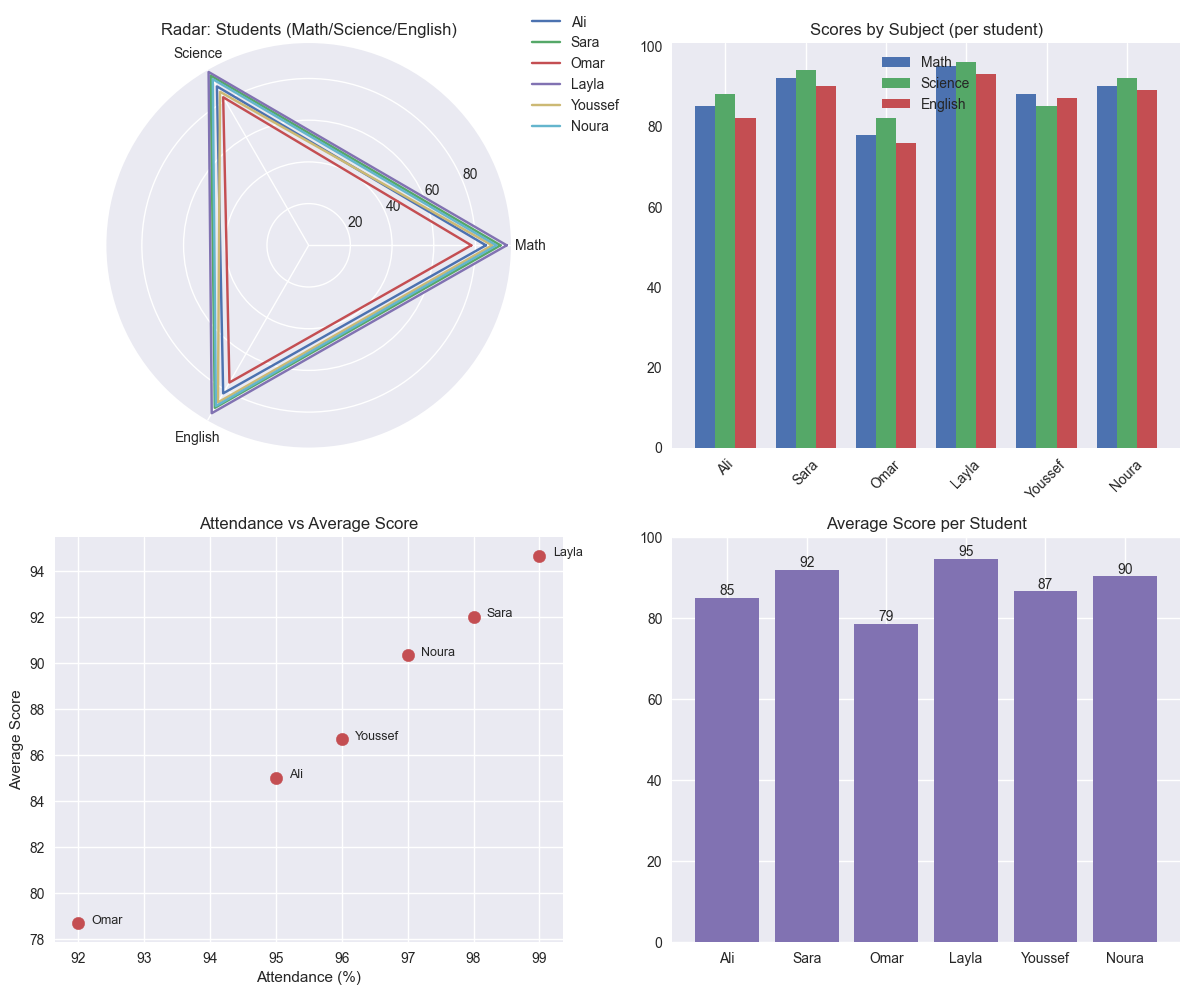

In [63]:
# Q10 - Student performance visualizations (clean and beginner-friendly)
students = ['Ali', 'Sara', 'Omar', 'Layla', 'Youssef', 'Noura']
math_scores = [85, 92, 78, 95, 88, 90]
science_scores = [88, 94, 82, 96, 85, 92]
english_scores = [82, 90, 76, 93, 87, 89]
attendance = [95, 98, 92, 99, 96, 97]

# Compute average score per student
avg_scores = np.array([ (m + s + e) / 3 for m, s, e in zip(math_scores, science_scores, english_scores)])

# Create figure and dedicated axes for each subplot
fig = plt.figure(figsize=(12, 10))
radar_ax = fig.add_subplot(2, 2, 1, projection='polar')  # top-left
ax2 = fig.add_subplot(2, 2, 2)  # top-right
ax3 = fig.add_subplot(2, 2, 3)  # bottom-left
ax4 = fig.add_subplot(2, 2, 4)  # bottom-right

# Top-left: Radar chart (each student as a line)
subjects = ['Math', 'Science', 'English']
angles = np.linspace(0, 2 * np.pi, len(subjects), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  # close the loop
for i, name in enumerate(students):
    vals = np.array([math_scores[i], science_scores[i], english_scores[i]])
    vals = np.concatenate([vals, [vals[0]]])
    radar_ax.plot(angles, vals, label=name)
radar_ax.set_title('Radar: Students (Math/Science/English)')
radar_ax.set_xticks(angles[:-1])
radar_ax.set_xticklabels(subjects)
radar_ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Top-right: Grouped bar chart comparing subjects across students
x = np.arange(len(students))
width = 0.25
ax2.bar(x - width, math_scores, width, label='Math')
ax2.bar(x, science_scores, width, label='Science')
ax2.bar(x + width, english_scores, width, label='English')
ax2.set_xticks(x)
ax2.set_xticklabels(students, rotation=45)
ax2.set_title('Scores by Subject (per student)')
ax2.legend()
ax2.grid(axis='y')

# Bottom-left: Scatter plot attendance vs average score
ax3.scatter(attendance, avg_scores, s=80, c='C2')
for i, name in enumerate(students):
    ax3.text(attendance[i] + 0.2, avg_scores[i], name, fontsize=9)
ax3.set_xlabel('Attendance (%)')
ax3.set_ylabel('Average Score')
ax3.set_title('Attendance vs Average Score')
ax3.grid(True)

# Bottom-right: Average score per student (simple bar)
ax4.bar(students, avg_scores, color='C3')
for i, v in enumerate(avg_scores):
    ax4.text(i, v, f'{v:.0f}', ha='center', va='bottom')
ax4.set_title('Average Score per Student')
ax4.set_ylim(0, 100)

plt.tight_layout()
plt.show()